<a href="https://colab.research.google.com/github/MozaRex9/fft-case-studies-template/blob/main/Selamat_Datang_di_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!wget https://github.com/MozaRex9/fft-case-studies-template/blob/main/data/sunspots.csv

--2026-05-28 12:18:39--  https://github.com/MozaRex9/fft-case-studies-template/blob/main/data/sunspots.csv
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘sunspots.csv’

sunspots.csv            [ <=>                ] 621.52K  --.-KB/s    in 0.06s   

2026-05-28 12:18:40 (9.39 MB/s) - ‘sunspots.csv’ saved [636439]



--2026-05-28 12:47:43--  https://raw.githubusercontent.com/MozaRex9/fft-case-studies-template/main/data/sunspots.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 71184 (70K) [text/plain]
Saving to: ‘sunspots.csv’

sunspots.csv        100%[===================>]  69.52K  --.-KB/s    in 0.01s   

2026-05-28 12:47:43 (5.15 MB/s) - ‘sunspots.csv’ saved [71184/71184]

   Unnamed: 0        Date  Monthly Mean Total Sunspot Number
0           0  1749-01-31                               96.7
1           1  1749-02-28                              104.3
2           2  1749-03-31                              116.7
3           3  1749-04-30                               92.8
4           4  1749-05-31                              141.7


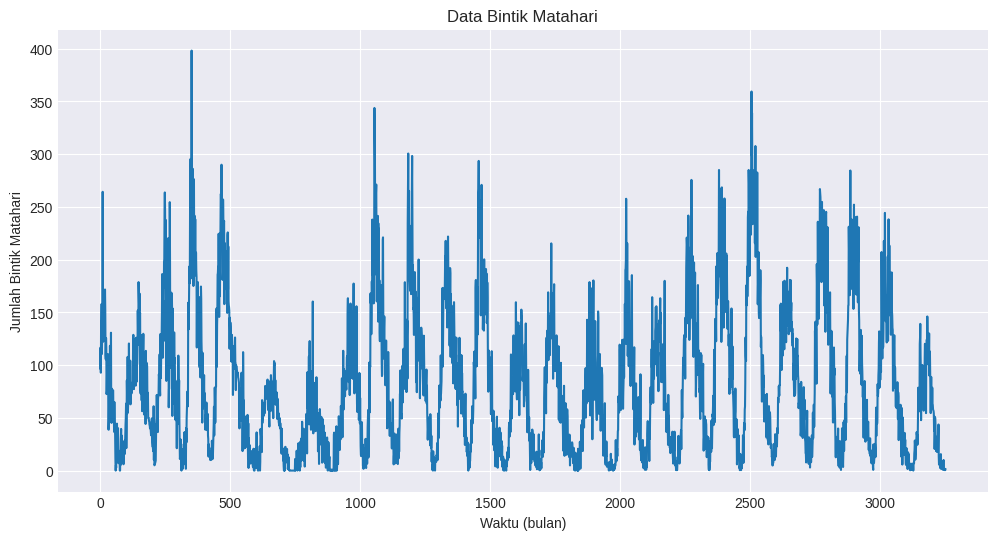

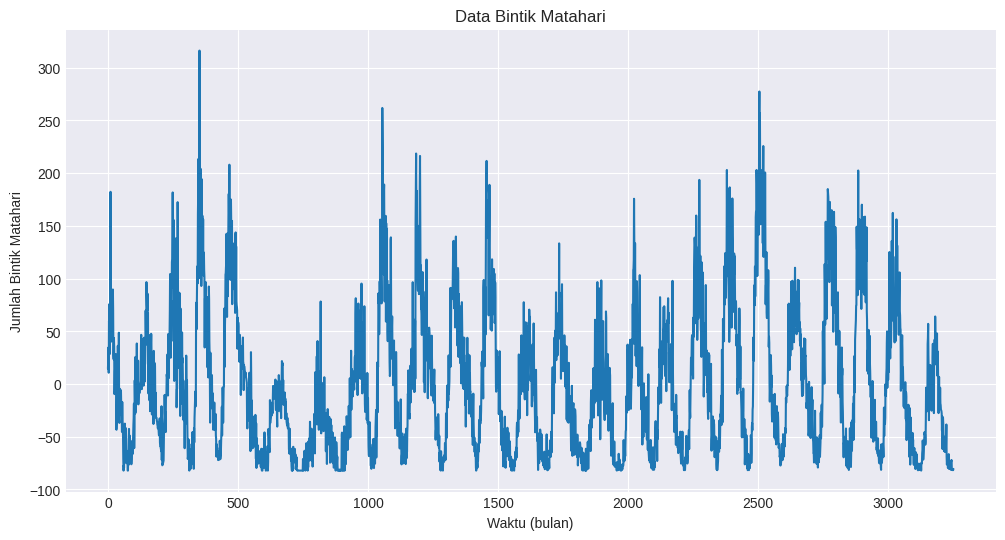

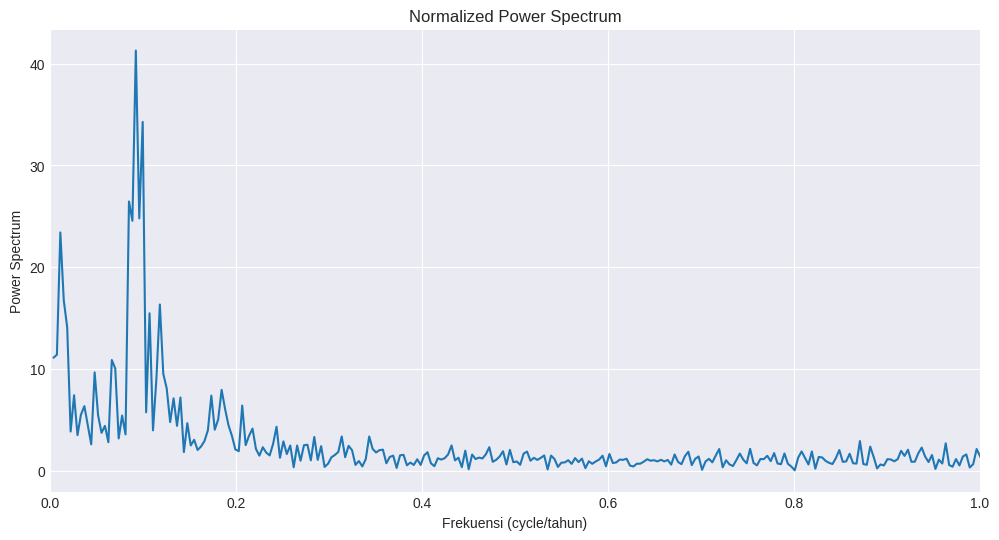

HASIL ANALISIS FFT
Frekuensi Dominan = 0.0923 cycle/tahun
Periode Dominan   = 10.84 tahun


In [5]:
# ============================================
# FFT DAN NORMALIZED POWER SPECTRUM
# DATA BINTIK MATAHARI
# ============================================

# Import library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Style plot
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12,6)

# ------------------------------------------------
# 1. BACA DATA CSV
# ------------------------------------------------
# Ganti nama file jika berbeda
!wget -O sunspots.csv https://raw.githubusercontent.com/MozaRex9/fft-case-studies-template/main/data/sunspots.csv
data = pd.read_csv('sunspots.csv')

# Tampilkan beberapa data awal
print(data.head())

# ------------------------------------------------
# 2. AMBIL DATA JUMLAH BINTIK MATAHARI
# ------------------------------------------------
# Ganti 'Sunspots' sesuai nama kolom pada file CSV

y = data['Monthly Mean Total Sunspot Number'].values

# ------------------------------------------------
# 11. PLOT DATA ASLI
# ------------------------------------------------
plt.figure()

plt.plot(y)

plt.title('Data Bintik Matahari')
plt.xlabel('Waktu (bulan)')
plt.ylabel('Jumlah Bintik Matahari')

plt.show()

# ------------------------------------------------
# 4. HILANGKAN RATA-RATA DATA
# ------------------------------------------------
y = y - np.mean(y)

plt.figure()

plt.plot(y)

plt.title('Data Bintik Matahari')
plt.xlabel('Waktu (bulan)')
plt.ylabel('Jumlah Bintik Matahari')

plt.show()


# ------------------------------------------------
# 3. JUMLAH DATA DAN INTERVAL SAMPLING
# ------------------------------------------------
N = len(y)

# Sampling interval:
# 1 bulan = 1/12 tahun

dt = 1/12

# ------------------------------------------------
# 5. HITUNG FFT
# ------------------------------------------------
Y = np.fft.fft(y)

# ------------------------------------------------
# 6. HITUNG FREKUENSI
# ------------------------------------------------
freq = np.fft.fftfreq(N, d=dt)

# ------------------------------------------------
# 7. HITUNG NORMALIZED POWER SPECTRUM
# ------------------------------------------------
P = (2/N) * np.abs(Y)

# ------------------------------------------------
# 8. AMBIL FREKUENSI POSITIF SAJA
# ------------------------------------------------
positive = freq > 0

freq_pos = freq[positive]
P_pos = P[positive]

# ------------------------------------------------
# 9. CARI FREKUENSI DOMINAN
# ------------------------------------------------
index_max = np.argmax(P_pos)

f_max = freq_pos[index_max]

# Periode dominan (tahun)
T = 1 / f_max


# ------------------------------------------------
# 12. PLOT POWER SPECTRUM
# ------------------------------------------------
plt.figure()

plt.plot(freq_pos, P_pos)

plt.title('Normalized Power Spectrum')
plt.xlabel('Frekuensi (cycle/tahun)')
plt.ylabel('Power Spectrum')

plt.xlim(0, 1)

plt.show()

# ------------------------------------------------
# 10. TAMPILKAN HASIL
# ------------------------------------------------
print("===================================")
print("HASIL ANALISIS FFT")
print("===================================")

print(f"Frekuensi Dominan = {f_max:.4f} cycle/tahun")
print(f"Periode Dominan   = {T:.2f} tahun")

